# Тренування YOLOv1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import yaml
from PIL import Image
from pathlib import Path
import logging
import os
import random


import matplotlib.pyplot as plt
import matplotlib.patches as patches

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

device = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = device

### Реалізація необхідних класів

In [ ]:
class YOLODataset(Dataset):
    """
    Arguments:
        img_dir (str): Path to directory with images (example: 'train/images').
        label_dir (str): Path to directory with labels (example 'train/labels').
        yaml_path (str, optional): Path to class_weights.yaml file.
        transform (callable, optional): Transformations for an image.
    """
    def __init__(self, img_dir, label_dir, yaml_path=None, transform=None):
        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.transform = transform
        self.class_weights_dict = None

        if yaml_path:
            yaml_p = Path(yaml_path)
            if yaml_p.exists():
                with open(yaml_p, 'r') as f:
                    self.class_weights_dict = yaml.safe_load(f)
                logger.info(f"Loaded class weights from {yaml_path}")
            else:
                logger.warning(f"Weights file not found at {yaml_path}")

        self.image_files = sorted([
            f for f in self.img_dir.iterdir() 
            if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']
        ])
        
        self.valid_files = []
        for img_file in self.image_files:
            label_file = self.label_dir / (img_file.stem + '.txt')
            if label_file.exists():
                self.valid_files.append(img_file)
            else:
                logger.warning(f"No label file for: {img_file.name}")

        logger.info(f"Found {len(self.valid_files)} valid pairs image/label.")

    def __len__(self):
        return len(self.valid_files)

    def get_class_weights(self):
        """Повертає словник ваг для передачі у Loss Function"""
        return self.class_weights_dict

    def __getitem__(self, idx):
        img_path = self.valid_files[idx]
        
        try:
            image = Image.open(img_path).convert("RGB")
            img_width, img_height = image.size
        except Exception as e:
            logger.error(f"Error opening image {img_path}: {e}")
            return torch.zeros(3, 224, 224), {}

        label_path = self.label_dir / (img_path.stem + '.txt')
        boxes = [] 
        
        try:
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    
                    if len(parts) == 5:
                        boxes.append([float(p) for p in parts])
                    
                    elif len(parts) > 5:
                         logger.warning(f"Label format is not 5-digit YOLO at {label_path.name}")
                         boxes.append([float(p) for p in parts[:5]])
                    
            if not boxes:
                boxes = np.empty((0, 5), dtype=np.float32)
            else:
                boxes = np.array(boxes, dtype=np.float32)

        except Exception as e:
            logger.error(f"Error reading label file {label_path}: {e}")
            boxes = np.empty((0, 5), dtype=np.float32) 
            
        target = {}
        target["boxes"] = boxes 
        target["image_id"] = idx
        target["image_path"] = str(img_path)
        target["original_size"] = (img_width, img_height)

        if self.transform:
            image = self.transform(image)

        S = 7
        C = 11 
        target_matrix = torch.zeros((S, S, C + 5))
        
        for box in boxes:
            class_label, x, y, width, height = box
            class_label = int(class_label)

            i, j = int(S * y), int(S * x)

            x_cell, y_cell = S * x - j, S * y - i
            
            width_cell, height_cell = width * S, height * S 

            if target_matrix[i, j, C] == 0:
                target_matrix[i, j, C] = 1

                target_matrix[i, j, C+1:C+5] = torch.tensor([x_cell, y_cell, width, height])
                
                target_matrix[i, j, class_label] = 1

        return image, target_matrix

In [3]:
ARCHITECTURE_CONFIG = [
    (7, 64, 2, 3),
    "M",
    (3, 192, 1, 1),
    "M",
    (1, 128, 1, 0),
    (3, 256, 1, 1),
    (1, 256, 1, 0),
    (3, 512, 1, 1),
    "M",
    # List: [Conv1x1, Conv3x3, repeat]
    [(1, 256, 1, 0), (3, 512, 1, 1), 4],
    (1, 512, 1, 0),
    (3, 1024, 1, 1),
    "M",
    [(1, 512, 1, 0), (3, 1024, 1, 1), 2],
    (3, 1024, 1, 1),
    (3, 1024, 2, 1),
    (3, 1024, 1, 1),
    (3, 1024, 1, 1),
]

In [ ]:
class CNNBlock(nn.Module):
    """Базовий будівельний блок: Conv -> BatchNorm -> LeakyReLU"""
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class YOLOv1(nn.Module):
    """
    Архітектура YOLO v1.
    Вихідний тензор: (batch_size, S, S, C + B * 5)
    """
    def __init__(self, in_channels=3, **kwargs):
        super(YOLOv1, self).__init__()
        self.architecture = ARCHITECTURE_CONFIG
        self.in_channels = in_channels
        self.darknet = self._create_conv_layers(self.architecture)
        self.fcs = self._create_fcs(**kwargs)
        
        logger.info("YOLOv1 model initialized successfully.")

    def forward(self, x):
        x = self.darknet(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fcs(x)
        return x

    def _create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if type(x) == tuple:
                kernel_size, num_filters, stride, padding = x
                layers.append(
                    CNNBlock(
                        in_channels, 
                        num_filters, 
                        kernel_size=kernel_size, 
                        stride=stride, 
                        padding=padding
                    )
                )
                in_channels = num_filters

            elif type(x) == str:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            elif type(x) == list:
                conv1 = x[0] # Tuple
                conv2 = x[1] # Tuple
                num_repeats = x[2] # Int

                for _ in range(num_repeats):
                    layers.append(
                        CNNBlock(
                            in_channels,
                            conv1[1],
                            kernel_size=conv1[0],
                            stride=conv1[2],
                            padding=conv1[3],
                        )
                    )
                    layers.append(
                        CNNBlock(
                            conv1[1],
                            conv2[1],
                            kernel_size=conv2[0],
                            stride=conv2[2],
                            padding=conv2[3],
                        )
                    )
                    in_channels = conv2[1]

        return nn.Sequential(*layers)

    def _create_fcs(self, split_size, num_boxes, num_classes):
        """
        Створення Fully Connected шарів.
        В оригінальній статті:
        Flatten -> FC(4096) -> Dropout(0.5) -> FC(S*S*(C+B*5))
        """
        S, B, C = split_size, num_boxes, num_classes
        
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(4096, S * S * (C + B * 5)), 
        )

In [ ]:
import torchvision.transforms as transforms

NUM_CLASSES = 11 
GRID_SIZE = 7   # S
NUM_BBOXES = 2  # B

model = YOLOv1(
    split_size=GRID_SIZE, 
    num_boxes=NUM_BBOXES, 
    num_classes=NUM_CLASSES
).to(device)

logger.info(f"Model created with Grid: {GRID_SIZE}x{GRID_SIZE}, Classes: {NUM_CLASSES}")

INFO:__main__:YOLOv1 model initialized successfully.
INFO:__main__:Model created with Grid: 7x7, Classes: 11


### Тестування архітектури

In [ ]:
def test_yolo_architecture():
    S = 7
    B = 2
    C = 11
    model = YOLOv1(split_size=S, num_boxes=B, num_classes=C)
    
    x = torch.randn((2, 3, 448, 448))
    
    try:
        out = model(x)
        expected_dim = S * S * (C + B * 5)
        logger.info(f"Output shape: {out.shape}")
        
        assert out.shape == (2, expected_dim)
        print("Success! Output shape is correct.")
        
        out = out.reshape(-1, S, S, C + B * 5)
        print(f"Reshaped output: {out.shape}") # (2, 7, 7, 30)
        
    except Exception as e:
        logger.error(f"Architecture test failed: {e}")

test_yolo_architecture()

INFO:__main__:YOLOv1 model initialized successfully.
INFO:__main__:Output shape: torch.Size([2, 1029])


Success! Output shape is correct.
Reshaped output: torch.Size([2, 7, 7, 21])


### Наші ваги класів

In [ ]:
class_weights_dict = {
    3: 1.4484, 9: 0.2572, 10: 1.8922, 8: 0.3447, 7: 10.2017, 
    2: 1.5935, 4: 8.8543, 5: 9.8795, 1: 19.1542
}

def get_class_weights_tensor(weights_dict, num_classes, device):
    weights = torch.ones(num_classes, dtype=torch.float32)
    
    if weights_dict:
        for class_id, weight in weights_dict.items():
            if class_id < num_classes:
                weights[class_id] = weight
            else:
                logger.warning(f"Class ID {class_id} in weights dict exceeds NUM_CLASSES {num_classes}")
    
    return weights.to(device)

class_weights_tensor = get_class_weights_tensor(class_weights_dict, NUM_CLASSES, device)

logger.info(f"Weights tensor shape: {class_weights_tensor.shape}") 

INFO:__main__:Weights tensor shape: torch.Size([11])


### IoU та Loss-Функція

In [10]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    """
    Розраховує IoU (Intersection over Union).
    boxes_preds shape: (N, 4) де N - кількість боксів
    boxes_labels shape: (N, 4)
    box_format: "midpoint" (x, y, w, h) - стандарт для YOLO
    """
    
    # Конвертація з (x, y, w, h) в (x1, y1, x2, y2) для розрахунків
    box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
    box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
    box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
    box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

    box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
    box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
    box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
    box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    # .clamp(0) гарантує, що якщо перетину немає, площа буде 0
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

In [ ]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=11, class_weights=None):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5.0
        self.class_weights = class_weights

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)

        iou_b1 = intersection_over_union(predictions[..., self.C + 1:self.C + 5], target[..., self.C + 1:self.C + 5])
        iou_b2 = intersection_over_union(predictions[..., self.C + 6:self.C + 10], target[..., self.C + 1:self.C + 5])
        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)
        
        iou_maxes, bestbox = torch.max(ious, dim=0)
        exists_box = target[..., self.C].unsqueeze(3) 

        box_predictions = exists_box * (
            (bestbox * predictions[..., self.C + 6:self.C + 10] + (1 - bestbox) * predictions[..., self.C + 1:self.C + 5])
        )
        box_targets = exists_box * target[..., self.C + 1:self.C + 5]

        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(torch.abs(box_predictions[..., 2:4] + 1e-6))
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(torch.flatten(box_predictions, end_dim=-2), torch.flatten(box_targets, end_dim=-2))

        pred_box = (bestbox * predictions[..., self.C + 5:self.C + 6] + (1 - bestbox) * predictions[..., self.C:self.C + 1])
        object_loss = self.mse(torch.flatten(exists_box * pred_box), torch.flatten(exists_box * target[..., self.C:self.C + 1]))

        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C:self.C + 1], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C:self.C + 1], start_dim=1)
        )
        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C + 5:self.C + 6], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C:self.C + 1], start_dim=1)
        )

        pred_classes = predictions[..., :self.C]
        target_classes = target[..., :self.C]
        
        if self.class_weights is not None:
            squared_diff = (pred_classes - target_classes) ** 2 
            masked_diff = exists_box * squared_diff 
            class_loss = torch.sum(masked_diff * self.class_weights)
        else:
            class_loss = self.mse(torch.flatten(exists_box * pred_classes, end_dim=-2), torch.flatten(exists_box * target_classes, end_dim=-2))

        loss = (self.lambda_coord * box_loss + object_loss + self.lambda_noobj * no_object_loss + class_loss)
        return loss

In [13]:
def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
    logger.info(f"=> Saving checkpoint to {filename}")
    torch.save(state, filename)

### Тренування

In [ ]:
LEARNING_RATE = 2e-5
BATCH_SIZE = 16 
WEIGHT_DECAY = 0
EPOCHS = 10
NUM_CLASSES = 11

class_weights_dict = {
    3: 1.4484, 9: 0.2572, 10: 1.8922, 8: 0.3447, 7: 10.2017, 
    2: 1.5935, 4: 8.8543, 5: 9.8795, 1: 19.1542
}
weights_tensor = get_class_weights_tensor(class_weights_dict, NUM_CLASSES, device)

transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
])

train_dataset = YOLODataset(
    img_dir="data/train/images", 
    label_dir="data/train/labels",
    transform=transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True 
)

os.makedirs("weights", exist_ok=True)

model = YOLOv1(split_size=7, num_boxes=2, num_classes=NUM_CLASSES).to(device)
loss_fn = YoloLoss(S=7, B=2, C=NUM_CLASSES, class_weights=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

model.train()
    
for epoch in range(EPOCHS):
    loop_loss = 0
    
    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = loss_fn(out, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loop_loss += loss.item()
        
        if batch_idx % 10 == 0:
            logger.info(f"Epoch [{epoch+1}/{EPOCHS}] Batch {batch_idx} Loss: {loss.item():.4f}")

    avg_loss = loop_loss / len(train_loader)
    logger.info(f"=== Epoch {epoch+1} finished. Avg Loss: {avg_loss:.4f} ===")

    if (epoch + 1) % 5 == 0:
        checkpoint = {
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
        }
        save_path = f"weights/yolo_epoch_{epoch+1}.pth.tar"
        save_checkpoint(checkpoint, filename=save_path)

INFO:__main__:Found 4467 valid pairs image/label.
INFO:__main__:YOLOv1 model initialized successfully.
INFO:__main__:Epoch [1/10] Batch 0 Loss: 298.5930
INFO:__main__:Epoch [1/10] Batch 10 Loss: 243.9035
INFO:__main__:Epoch [1/10] Batch 20 Loss: 236.5541
INFO:__main__:Epoch [1/10] Batch 30 Loss: 155.9352
INFO:__main__:Epoch [1/10] Batch 40 Loss: 190.4318
INFO:__main__:Epoch [1/10] Batch 50 Loss: 169.0652
INFO:__main__:Epoch [1/10] Batch 60 Loss: 135.6208
INFO:__main__:Epoch [1/10] Batch 70 Loss: 133.9204
INFO:__main__:Epoch [1/10] Batch 80 Loss: 123.7071
INFO:__main__:Epoch [1/10] Batch 90 Loss: 64.1182
INFO:__main__:Epoch [1/10] Batch 100 Loss: 120.0509
INFO:__main__:Epoch [1/10] Batch 110 Loss: 80.9216
INFO:__main__:Epoch [1/10] Batch 120 Loss: 114.7497
INFO:__main__:Epoch [1/10] Batch 130 Loss: 79.5199
INFO:__main__:Epoch [1/10] Batch 140 Loss: 76.8138
INFO:__main__:Epoch [1/10] Batch 150 Loss: 91.8632
INFO:__main__:Epoch [1/10] Batch 160 Loss: 89.1246
INFO:__main__:Epoch [1/10] Bat

### Допоміжні функції для зображення виводу моделі

In [ ]:
def non_max_suppression(bboxes, iou_threshold, threshold, box_format="corners"):
    """
    bboxes: list of lists [[class_pred, prob_score, x1, y1, x2, y2], ...]
    """
    assert type(bboxes) == list

    bboxes = [box for box in bboxes if box[1] > threshold]
    
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    bboxes_after_nms = []

    while bboxes:
        chosen_box = bboxes.pop(0)

        bboxes = [
            box for box in bboxes
            if box[0] != chosen_box[0] # Якщо класи різні — залишаємо
            or intersection_over_union(
                torch.tensor(chosen_box[2:]).unsqueeze(0),
                torch.tensor(box[2:]).unsqueeze(0),
                box_format=box_format
            ) < iou_threshold # Якщо перекриття мале — залишаємо
        ]

        bboxes_after_nms.append(chosen_box)

    return bboxes_after_nms

In [ ]:
def convert_cellboxes(predictions, S=7):
    """
    Конвертує вихід YOLO (S, S, 21) назад у список боксів для всього зображення.
    Повертає бокси у форматі: [class_index, best_confidence, x1, y1, x2, y2]
    """
    predictions = predictions.to("cpu")
    batch_size = predictions.shape[0]
    
    predictions = predictions.reshape(batch_size, 7, 7, 21) 
    
    bboxes1 = predictions[..., 11:15] 
    bboxes2 = predictions[..., 16:20] 
    
    scores = torch.cat(
        (predictions[..., 11].unsqueeze(0), predictions[..., 16].unsqueeze(0)), dim=0
    )
    
    best_box = scores.argmax(0).unsqueeze(-1) 
    
    best_boxes = bboxes1 * (1 - best_box) + bboxes2 * best_box

    cell_indices = torch.arange(7).repeat(batch_size, 7, 1).unsqueeze(-1)
    
    x = 1 / S * (best_boxes[..., :1] + cell_indices)
    y = 1 / S * (best_boxes[..., 1:2] + cell_indices.permute(0, 2, 1, 3))
    w_h = 1 / S * best_boxes[..., 2:4]
    
    converted_bboxes = torch.cat((x, y, w_h), dim=-1)

    predicted_class = predictions[..., :11].argmax(-1).unsqueeze(-1)
    best_confidence = torch.max(predictions[..., 11], predictions[..., 16]).unsqueeze(-1)
    
    converted_preds = torch.cat(
        (predicted_class, best_confidence, converted_bboxes), dim=-1
    )

    return converted_preds

In [ ]:
def plot_image(image, boxes, class_labels):
    """
    Малює бокси на зображенні.
    """
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()

    im = np.array(image)
    height, width, _ = im.shape

    fig, ax = plt.subplots(1, figsize=(8, 8)) 
    ax.imshow(im)
    
    ax.axis('off')

    for box in boxes:
        class_id = int(box[0])
        prob = box[1]
        coords = box[2:]
        
        x1 = coords[0] * width
        y1 = coords[1] * height
        x2 = coords[2] * width
        y2 = coords[3] * height
        
        box_width = x2 - x1
        box_height = y2 - y1

        rect = patches.Rectangle(
            (x1, y1), 
            box_width, 
            box_height, 
            linewidth=3,       
            edgecolor='red',   
            facecolor='none'   
        )
        ax.add_patch(rect)

        label_text = f"{class_labels[class_id]} ({prob:.2f})" if class_labels else f"Class {class_id} ({prob:.2f})"
        
        ax.text(
            x1, y1 - 5, 
            label_text, 
            color='white', 
            fontsize=10, 
            fontweight='bold',
            bbox=dict(facecolor='red', edgecolor='red', alpha=0.8, pad=2) 
        )

    plt.show()

In [ ]:
def cellboxes_to_boxes(out, S=7, C=11):
    """
    Перетворює вихід нейромережі (Batch, S*S*(C+B*5)) у список боксів
    для подальшої обробки (NMS).
    
    Повертає список списків: [[class_index, confidence, x1, y1, x2, y2], ...]
    """
    out = out.to("cpu")
    batch_size = out.shape[0]
    
    predictions = out.reshape(batch_size, S, S, C + 10)
    
    predicted_class = predictions[..., :C].argmax(-1).unsqueeze(-1) 
    best_class_prob = predictions[..., :C].max(-1)[0].unsqueeze(-1) 
    
    score1 = predictions[..., C].unsqueeze(-1)
    score2 = predictions[..., C + 5].unsqueeze(-1)
    
    scores = torch.cat((score1, score2), dim=-1)
    best_score, best_box_idx = torch.max(scores, dim=-1)
    best_score = best_score.unsqueeze(-1)
    best_box_idx = best_box_idx.unsqueeze(-1) 
    
    box1_specs = predictions[..., C+1:C+5]
    box2_specs = predictions[..., C+6:C+10]
    
    best_boxes = box1_specs * (1 - best_box_idx) + box2_specs * best_box_idx
    
    cell_indices = torch.arange(S).repeat(batch_size, S, 1).unsqueeze(-1)
    
    # (x_cell + index_x) / S
    x = 1 / S * (best_boxes[..., 0:1] + cell_indices)
    y = 1 / S * (best_boxes[..., 1:2] + cell_indices.permute(0, 2, 1, 3))
    
    w_h = 1 / S * best_boxes[..., 2:4] 
    
    converted_bboxes = torch.cat((x, y, w_h), dim=-1)
    
    x1 = converted_bboxes[..., 0:1] - converted_bboxes[..., 2:3] / 2
    y1 = converted_bboxes[..., 1:2] - converted_bboxes[..., 3:4] / 2
    x2 = converted_bboxes[..., 0:1] + converted_bboxes[..., 2:3] / 2
    y2 = converted_bboxes[..., 1:2] + converted_bboxes[..., 3:4] / 2
    
    pred_boxes = torch.cat((predicted_class, best_score, x1, y1, x2, y2), dim=-1)

    all_bboxes = []
    for batch_idx in range(batch_size):
        bboxes = pred_boxes[batch_idx].reshape(-1, 6).tolist()
        all_bboxes.append(bboxes)

    return all_bboxes

### Результат моделі

In [ ]:
def main_inference():

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_CLASSES = 11

    CLASS_LABELS = [
        "Class0", "Class1", "Class2", "Class3", "Class4", 
        "Class5", "Class6", "Class7", "Class8", "Class9", "Class10"
    ]
    
    model = YOLOv1(split_size=7, num_boxes=2, num_classes=NUM_CLASSES)
    
    checkpoint_path = "weights/yolo_epoch_10.pth.tar" 
    
    if os.path.exists(checkpoint_path):
        logger.info(f"Loading checkpoint {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

        model.load_state_dict(checkpoint["state_dict"])

        model = model.to(DEVICE)
    else:
        logger.error("Checkpoint not found!")
        return

    model.eval() 

    img_dir = Path("data/train/images") 

    if not img_dir.exists():
        img_dir = Path("data/train")

    all_images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))

    if len(all_images) > 0:
        test_img_path = random.choice(all_images)
        logger.info(f"Testing on image: {test_img_path}")
    else:
        logger.error(f"No images found in {img_dir}")
        return

    try:
        img_raw = Image.open(test_img_path).convert("RGB")
    except Exception as e:
        logger.error(f"Error opening image: {e}")
        return

    import torchvision.transforms as transforms
    transform = transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.ToTensor(),
    ])
    
    x = transform(img_raw).unsqueeze(0).to(DEVICE) 

    with torch.no_grad():
        out = model(x)
        
        bboxes = cellboxes_to_boxes(out, S=7, C=NUM_CLASSES)

        bboxes = bboxes[0] 

        nms_bboxes = non_max_suppression(bboxes, iou_threshold=0.5, threshold=0.4, box_format="corners")

    plot_image(img_raw.resize((448, 448)), nms_bboxes, CLASS_LABELS)

INFO:__main__:YOLOv1 model initialized successfully.
INFO:__main__:Loading checkpoint weights/yolo_epoch_10.pth.tar
INFO:__main__:Testing on image: data\train\images\-FPV-_mp4-0066_jpg.rf.23fe0ff2ff9155a48f76143dcb8d4e7f.jpg


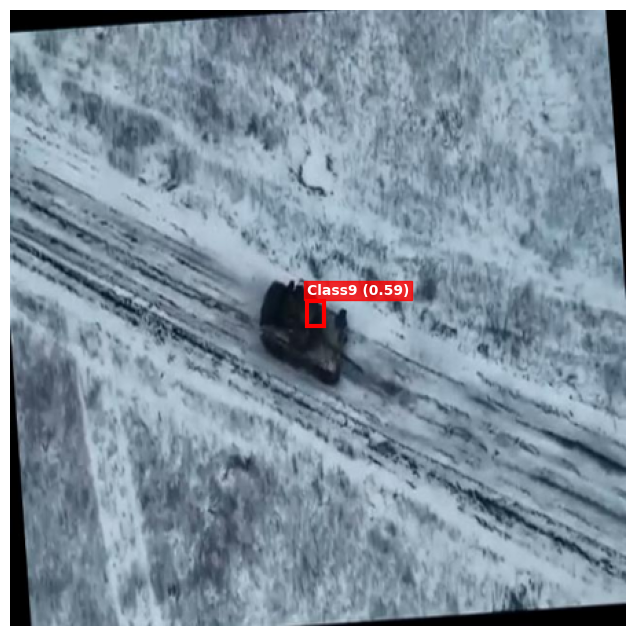

In [32]:
main_inference()

### Графіки втрат

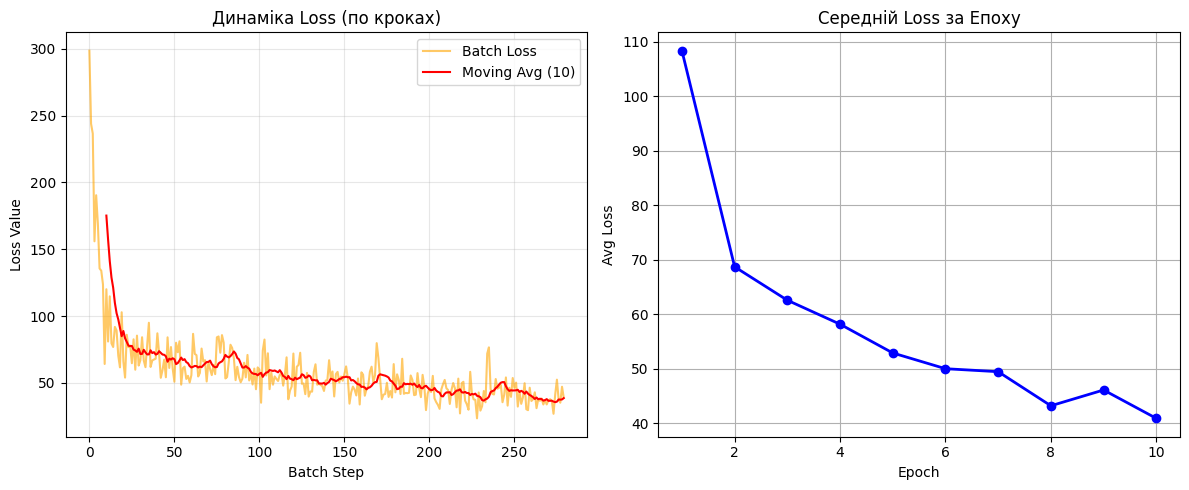

In [ ]:
import re

def plot_loss_curve(log_content):
    """
    Парсить текст логів і малює графік.
    Очікує формат: "Batch X Loss: Y" або "Avg Loss: Y"
    """
    batch_losses = []
    epoch_losses = []
    
    batch_pattern = re.compile(r"Batch\s+\d+\s+Loss:\s+([\d\.]+)")

    epoch_pattern = re.compile(r"Avg Loss:\s+([\d\.]+)")

    for line in log_content.split('\n'):
        batch_match = batch_pattern.search(line)
        if batch_match:
            batch_losses.append(float(batch_match.group(1)))

        epoch_match = epoch_pattern.search(line)
        if epoch_match:
            epoch_losses.append(float(epoch_match.group(1)))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(batch_losses, label='Batch Loss', color='orange', alpha=0.6)

    if len(batch_losses) > 10:
        ma = [sum(batch_losses[i:i+10])/10 for i in range(len(batch_losses)-10)]
        plt.plot(range(10, len(batch_losses)), ma, color='red', label='Moving Avg (10)')
    
    plt.title("Динаміка Loss (по кроках)")
    plt.xlabel("Batch Step")
    plt.ylabel("Loss Value")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    if epoch_losses:
        plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o', color='blue', linewidth=2)
        plt.title("Середній Loss за Епоху")
        plt.xlabel("Epoch")
        plt.ylabel("Avg Loss")
        plt.grid(True)
    else:
        plt.text(0.5, 0.5, "Не знайдено записів 'Avg Loss'", ha='center')

    plt.tight_layout()
    plt.show()


logs = """
INFO:__main__:Epoch [1/10] Batch 0 Loss: 298.5930
INFO:__main__:Epoch [1/10] Batch 10 Loss: 243.9035
INFO:__main__:Epoch [1/10] Batch 20 Loss: 236.5541
INFO:__main__:Epoch [1/10] Batch 30 Loss: 155.9352
INFO:__main__:Epoch [1/10] Batch 40 Loss: 190.4318
INFO:__main__:Epoch [1/10] Batch 50 Loss: 169.0652
INFO:__main__:Epoch [1/10] Batch 60 Loss: 135.6208
INFO:__main__:Epoch [1/10] Batch 70 Loss: 133.9204
INFO:__main__:Epoch [1/10] Batch 80 Loss: 123.7071
INFO:__main__:Epoch [1/10] Batch 90 Loss: 64.1182
INFO:__main__:Epoch [1/10] Batch 100 Loss: 120.0509
INFO:__main__:Epoch [1/10] Batch 110 Loss: 80.9216
INFO:__main__:Epoch [1/10] Batch 120 Loss: 114.7497
INFO:__main__:Epoch [1/10] Batch 130 Loss: 79.5199
INFO:__main__:Epoch [1/10] Batch 140 Loss: 76.8138
INFO:__main__:Epoch [1/10] Batch 150 Loss: 91.8632
INFO:__main__:Epoch [1/10] Batch 160 Loss: 89.1246
INFO:__main__:Epoch [1/10] Batch 170 Loss: 70.3617
INFO:__main__:Epoch [1/10] Batch 180 Loss: 61.5839
INFO:__main__:Epoch [1/10] Batch 190 Loss: 102.8320
INFO:__main__:Epoch [1/10] Batch 200 Loss: 65.9278
INFO:__main__:Epoch [1/10] Batch 210 Loss: 53.9139
INFO:__main__:Epoch [1/10] Batch 220 Loss: 85.9579
INFO:__main__:Epoch [1/10] Batch 230 Loss: 76.7074
INFO:__main__:Epoch [1/10] Batch 240 Loss: 77.8801
INFO:__main__:Epoch [1/10] Batch 250 Loss: 64.6718
INFO:__main__:Epoch [1/10] Batch 260 Loss: 82.5808
INFO:__main__:Epoch [1/10] Batch 270 Loss: 59.8342
INFO:__main__:=== Epoch 1 finished. Avg Loss: 108.3192 ===
INFO:__main__:Epoch [2/10] Batch 0 Loss: 85.3403
INFO:__main__:Epoch [2/10] Batch 10 Loss: 62.9279
INFO:__main__:Epoch [2/10] Batch 20 Loss: 66.9413
INFO:__main__:Epoch [2/10] Batch 30 Loss: 84.1243
INFO:__main__:Epoch [2/10] Batch 40 Loss: 66.7037
INFO:__main__:Epoch [2/10] Batch 50 Loss: 61.7343
INFO:__main__:Epoch [2/10] Batch 60 Loss: 78.0821
INFO:__main__:Epoch [2/10] Batch 70 Loss: 94.9680
INFO:__main__:Epoch [2/10] Batch 80 Loss: 61.9131
INFO:__main__:Epoch [2/10] Batch 90 Loss: 66.7864
INFO:__main__:Epoch [2/10] Batch 100 Loss: 67.4487
INFO:__main__:Epoch [2/10] Batch 110 Loss: 68.0930
INFO:__main__:Epoch [2/10] Batch 120 Loss: 87.0671
INFO:__main__:Epoch [2/10] Batch 130 Loss: 72.2084
INFO:__main__:Epoch [2/10] Batch 140 Loss: 53.7730
INFO:__main__:Epoch [2/10] Batch 150 Loss: 59.4194
INFO:__main__:Epoch [2/10] Batch 160 Loss: 67.3413
INFO:__main__:Epoch [2/10] Batch 170 Loss: 54.1550
INFO:__main__:Epoch [2/10] Batch 180 Loss: 84.0524
INFO:__main__:Epoch [2/10] Batch 190 Loss: 61.1336
INFO:__main__:Epoch [2/10] Batch 200 Loss: 76.7807
INFO:__main__:Epoch [2/10] Batch 210 Loss: 60.6813
INFO:__main__:Epoch [2/10] Batch 220 Loss: 50.8182
INFO:__main__:Epoch [2/10] Batch 230 Loss: 80.0088
INFO:__main__:Epoch [2/10] Batch 240 Loss: 72.9063
INFO:__main__:Epoch [2/10] Batch 250 Loss: 81.0862
INFO:__main__:Epoch [2/10] Batch 260 Loss: 48.6237
INFO:__main__:Epoch [2/10] Batch 270 Loss: 60.9689
INFO:__main__:=== Epoch 2 finished. Avg Loss: 68.6794 ===
INFO:__main__:Epoch [3/10] Batch 0 Loss: 62.1379
INFO:__main__:Epoch [3/10] Batch 10 Loss: 52.9078
INFO:__main__:Epoch [3/10] Batch 20 Loss: 55.2386
INFO:__main__:Epoch [3/10] Batch 30 Loss: 50.3137
INFO:__main__:Epoch [3/10] Batch 40 Loss: 55.7249
INFO:__main__:Epoch [3/10] Batch 50 Loss: 86.6821
INFO:__main__:Epoch [3/10] Batch 60 Loss: 71.6426
INFO:__main__:Epoch [3/10] Batch 70 Loss: 70.7303
INFO:__main__:Epoch [3/10] Batch 80 Loss: 54.7508
INFO:__main__:Epoch [3/10] Batch 90 Loss: 57.3896
INFO:__main__:Epoch [3/10] Batch 100 Loss: 75.6487
INFO:__main__:Epoch [3/10] Batch 110 Loss: 65.9129
INFO:__main__:Epoch [3/10] Batch 120 Loss: 66.9412
INFO:__main__:Epoch [3/10] Batch 130 Loss: 50.9991
INFO:__main__:Epoch [3/10] Batch 140 Loss: 65.4848
INFO:__main__:Epoch [3/10] Batch 150 Loss: 60.2882
INFO:__main__:Epoch [3/10] Batch 160 Loss: 55.7702
INFO:__main__:Epoch [3/10] Batch 170 Loss: 63.4974
INFO:__main__:Epoch [3/10] Batch 180 Loss: 56.4964
INFO:__main__:Epoch [3/10] Batch 190 Loss: 84.0564
INFO:__main__:Epoch [3/10] Batch 200 Loss: 84.7048
INFO:__main__:Epoch [3/10] Batch 210 Loss: 72.5321
INFO:__main__:Epoch [3/10] Batch 220 Loss: 85.7028
INFO:__main__:Epoch [3/10] Batch 230 Loss: 80.0996
INFO:__main__:Epoch [3/10] Batch 240 Loss: 53.2636
INFO:__main__:Epoch [3/10] Batch 250 Loss: 54.2903
INFO:__main__:Epoch [3/10] Batch 260 Loss: 65.5649
INFO:__main__:Epoch [3/10] Batch 270 Loss: 78.5056
INFO:__main__:=== Epoch 3 finished. Avg Loss: 62.5470 ===
INFO:__main__:Epoch [4/10] Batch 0 Loss: 76.0550
INFO:__main__:Epoch [4/10] Batch 10 Loss: 68.1876
INFO:__main__:Epoch [4/10] Batch 20 Loss: 52.0148
INFO:__main__:Epoch [4/10] Batch 30 Loss: 61.9867
INFO:__main__:Epoch [4/10] Batch 40 Loss: 54.3236
INFO:__main__:Epoch [4/10] Batch 50 Loss: 50.4272
INFO:__main__:Epoch [4/10] Batch 60 Loss: 53.0828
INFO:__main__:Epoch [4/10] Batch 70 Loss: 65.0252
INFO:__main__:Epoch [4/10] Batch 80 Loss: 54.0600
INFO:__main__:Epoch [4/10] Batch 90 Loss: 70.8870
INFO:__main__:Epoch [4/10] Batch 100 Loss: 51.7949
INFO:__main__:Epoch [4/10] Batch 110 Loss: 56.7314
INFO:__main__:Epoch [4/10] Batch 120 Loss: 48.7605
INFO:__main__:Epoch [4/10] Batch 130 Loss: 60.6647
INFO:__main__:Epoch [4/10] Batch 140 Loss: 45.2008
INFO:__main__:Epoch [4/10] Batch 150 Loss: 61.5352
INFO:__main__:Epoch [4/10] Batch 160 Loss: 59.9564
INFO:__main__:Epoch [4/10] Batch 170 Loss: 35.1126
INFO:__main__:Epoch [4/10] Batch 180 Loss: 74.1983
INFO:__main__:Epoch [4/10] Batch 190 Loss: 82.4027
INFO:__main__:Epoch [4/10] Batch 200 Loss: 55.5240
INFO:__main__:Epoch [4/10] Batch 210 Loss: 72.1122
INFO:__main__:Epoch [4/10] Batch 220 Loss: 45.2274
INFO:__main__:Epoch [4/10] Batch 230 Loss: 57.7518
INFO:__main__:Epoch [4/10] Batch 240 Loss: 48.5882
INFO:__main__:Epoch [4/10] Batch 250 Loss: 54.7899
INFO:__main__:Epoch [4/10] Batch 260 Loss: 52.9519
INFO:__main__:Epoch [4/10] Batch 270 Loss: 51.3798
INFO:__main__:=== Epoch 4 finished. Avg Loss: 58.1517 ===
INFO:__main__:Epoch [5/10] Batch 0 Loss: 56.0649
INFO:__main__:Epoch [5/10] Batch 10 Loss: 57.1486
INFO:__main__:Epoch [5/10] Batch 20 Loss: 47.9065
INFO:__main__:Epoch [5/10] Batch 30 Loss: 55.9554
INFO:__main__:Epoch [5/10] Batch 40 Loss: 69.0739
INFO:__main__:Epoch [5/10] Batch 50 Loss: 37.6972
INFO:__main__:Epoch [5/10] Batch 60 Loss: 44.1648
INFO:__main__:Epoch [5/10] Batch 70 Loss: 47.2449
INFO:__main__:Epoch [5/10] Batch 80 Loss: 71.9274
INFO:__main__:Epoch [5/10] Batch 90 Loss: 40.1513
INFO:__main__:Epoch [5/10] Batch 100 Loss: 62.0313
INFO:__main__:Epoch [5/10] Batch 110 Loss: 63.3733
INFO:__main__:Epoch [5/10] Batch 120 Loss: 72.5140
INFO:__main__:Epoch [5/10] Batch 130 Loss: 49.2923
INFO:__main__:Epoch [5/10] Batch 140 Loss: 49.5209
INFO:__main__:Epoch [5/10] Batch 150 Loss: 41.5222
INFO:__main__:Epoch [5/10] Batch 160 Loss: 57.4465
INFO:__main__:Epoch [5/10] Batch 170 Loss: 39.6813
INFO:__main__:Epoch [5/10] Batch 180 Loss: 43.5199
INFO:__main__:Epoch [5/10] Batch 190 Loss: 43.4021
INFO:__main__:Epoch [5/10] Batch 200 Loss: 58.1452
INFO:__main__:Epoch [5/10] Batch 210 Loss: 63.8643
INFO:__main__:Epoch [5/10] Batch 220 Loss: 48.6248
INFO:__main__:Epoch [5/10] Batch 230 Loss: 49.3456
INFO:__main__:Epoch [5/10] Batch 240 Loss: 48.4484
INFO:__main__:Epoch [5/10] Batch 250 Loss: 47.5544
INFO:__main__:Epoch [5/10] Batch 260 Loss: 43.9003
INFO:__main__:Epoch [5/10] Batch 270 Loss: 51.6724
INFO:__main__:=== Epoch 5 finished. Avg Loss: 52.8758 ===
INFO:__main__:=> Saving checkpoint to weights/yolo_epoch_5.pth.tar
INFO:__main__:Epoch [6/10] Batch 0 Loss: 52.0878
INFO:__main__:Epoch [6/10] Batch 10 Loss: 66.9263
INFO:__main__:Epoch [6/10] Batch 20 Loss: 53.2548
INFO:__main__:Epoch [6/10] Batch 30 Loss: 58.4865
INFO:__main__:Epoch [6/10] Batch 40 Loss: 39.8036
INFO:__main__:Epoch [6/10] Batch 50 Loss: 56.5975
INFO:__main__:Epoch [6/10] Batch 60 Loss: 58.2001
INFO:__main__:Epoch [6/10] Batch 70 Loss: 50.2626
INFO:__main__:Epoch [6/10] Batch 80 Loss: 54.7045
INFO:__main__:Epoch [6/10] Batch 90 Loss: 51.5626
INFO:__main__:Epoch [6/10] Batch 100 Loss: 56.5133
INFO:__main__:Epoch [6/10] Batch 110 Loss: 62.3165
INFO:__main__:Epoch [6/10] Batch 120 Loss: 53.7089
INFO:__main__:Epoch [6/10] Batch 130 Loss: 34.4072
INFO:__main__:Epoch [6/10] Batch 140 Loss: 42.9124
INFO:__main__:Epoch [6/10] Batch 150 Loss: 47.1592
INFO:__main__:Epoch [6/10] Batch 160 Loss: 44.8958
INFO:__main__:Epoch [6/10] Batch 170 Loss: 40.5373
INFO:__main__:Epoch [6/10] Batch 180 Loss: 53.2632
INFO:__main__:Epoch [6/10] Batch 190 Loss: 33.7871
INFO:__main__:Epoch [6/10] Batch 200 Loss: 57.8662
INFO:__main__:Epoch [6/10] Batch 210 Loss: 56.1265
INFO:__main__:Epoch [6/10] Batch 220 Loss: 40.3661
INFO:__main__:Epoch [6/10] Batch 230 Loss: 45.2765
INFO:__main__:Epoch [6/10] Batch 240 Loss: 47.4726
INFO:__main__:Epoch [6/10] Batch 250 Loss: 58.2863
INFO:__main__:Epoch [6/10] Batch 260 Loss: 62.0871
INFO:__main__:Epoch [6/10] Batch 270 Loss: 50.4023
INFO:__main__:=== Epoch 6 finished. Avg Loss: 49.9899 ===
INFO:__main__:Epoch [7/10] Batch 0 Loss: 55.5176
INFO:__main__:Epoch [7/10] Batch 10 Loss: 79.7017
INFO:__main__:Epoch [7/10] Batch 20 Loss: 68.5151
INFO:__main__:Epoch [7/10] Batch 30 Loss: 52.7197
INFO:__main__:Epoch [7/10] Batch 40 Loss: 37.6968
INFO:__main__:Epoch [7/10] Batch 50 Loss: 41.1511
INFO:__main__:Epoch [7/10] Batch 60 Loss: 41.6532
INFO:__main__:Epoch [7/10] Batch 70 Loss: 50.0479
INFO:__main__:Epoch [7/10] Batch 80 Loss: 39.4329
INFO:__main__:Epoch [7/10] Batch 90 Loss: 43.8825
INFO:__main__:Epoch [7/10] Batch 100 Loss: 38.9967
INFO:__main__:Epoch [7/10] Batch 110 Loss: 64.0229
INFO:__main__:Epoch [7/10] Batch 120 Loss: 42.8792
INFO:__main__:Epoch [7/10] Batch 130 Loss: 56.3685
INFO:__main__:Epoch [7/10] Batch 140 Loss: 52.0675
INFO:__main__:Epoch [7/10] Batch 150 Loss: 41.5964
INFO:__main__:Epoch [7/10] Batch 160 Loss: 68.0206
INFO:__main__:Epoch [7/10] Batch 170 Loss: 41.7851
INFO:__main__:Epoch [7/10] Batch 180 Loss: 42.4503
INFO:__main__:Epoch [7/10] Batch 190 Loss: 42.2542
INFO:__main__:Epoch [7/10] Batch 200 Loss: 42.5192
INFO:__main__:Epoch [7/10] Batch 210 Loss: 55.5160
INFO:__main__:Epoch [7/10] Batch 220 Loss: 52.2022
INFO:__main__:Epoch [7/10] Batch 230 Loss: 40.7681
INFO:__main__:Epoch [7/10] Batch 240 Loss: 41.1363
INFO:__main__:Epoch [7/10] Batch 250 Loss: 57.2623
INFO:__main__:Epoch [7/10] Batch 260 Loss: 45.6794
INFO:__main__:Epoch [7/10] Batch 270 Loss: 39.2853
INFO:__main__:=== Epoch 7 finished. Avg Loss: 49.4407 ===
INFO:__main__:Epoch [8/10] Batch 0 Loss: 55.9684
INFO:__main__:Epoch [8/10] Batch 10 Loss: 47.6373
INFO:__main__:Epoch [8/10] Batch 20 Loss: 29.5930
INFO:__main__:Epoch [8/10] Batch 30 Loss: 41.9688
INFO:__main__:Epoch [8/10] Batch 40 Loss: 45.7496
INFO:__main__:Epoch [8/10] Batch 50 Loss: 43.1093
INFO:__main__:Epoch [8/10] Batch 60 Loss: 55.2137
INFO:__main__:Epoch [8/10] Batch 70 Loss: 38.3223
INFO:__main__:Epoch [8/10] Batch 80 Loss: 35.5431
INFO:__main__:Epoch [8/10] Batch 90 Loss: 33.4928
INFO:__main__:Epoch [8/10] Batch 100 Loss: 30.5137
INFO:__main__:Epoch [8/10] Batch 110 Loss: 45.0388
INFO:__main__:Epoch [8/10] Batch 120 Loss: 48.9854
INFO:__main__:Epoch [8/10] Batch 130 Loss: 52.1851
INFO:__main__:Epoch [8/10] Batch 140 Loss: 45.9661
INFO:__main__:Epoch [8/10] Batch 150 Loss: 44.6146
INFO:__main__:Epoch [8/10] Batch 160 Loss: 34.1846
INFO:__main__:Epoch [8/10] Batch 170 Loss: 44.7186
INFO:__main__:Epoch [8/10] Batch 180 Loss: 49.8719
INFO:__main__:Epoch [8/10] Batch 190 Loss: 45.9624
INFO:__main__:Epoch [8/10] Batch 200 Loss: 31.6836
INFO:__main__:Epoch [8/10] Batch 210 Loss: 53.1555
INFO:__main__:Epoch [8/10] Batch 220 Loss: 27.0909
INFO:__main__:Epoch [8/10] Batch 230 Loss: 49.7749
INFO:__main__:Epoch [8/10] Batch 240 Loss: 50.7875
INFO:__main__:Epoch [8/10] Batch 250 Loss: 36.6429
INFO:__main__:Epoch [8/10] Batch 260 Loss: 33.9999
INFO:__main__:Epoch [8/10] Batch 270 Loss: 29.8670
INFO:__main__:=== Epoch 8 finished. Avg Loss: 43.1888 ===
INFO:__main__:Epoch [9/10] Batch 0 Loss: 58.2549
INFO:__main__:Epoch [9/10] Batch 10 Loss: 41.7767
INFO:__main__:Epoch [9/10] Batch 20 Loss: 37.6670
INFO:__main__:Epoch [9/10] Batch 30 Loss: 37.2485
INFO:__main__:Epoch [9/10] Batch 40 Loss: 23.4193
INFO:__main__:Epoch [9/10] Batch 50 Loss: 42.7705
INFO:__main__:Epoch [9/10] Batch 60 Loss: 29.2019
INFO:__main__:Epoch [9/10] Batch 70 Loss: 32.5776
INFO:__main__:Epoch [9/10] Batch 80 Loss: 43.8751
INFO:__main__:Epoch [9/10] Batch 90 Loss: 35.4618
INFO:__main__:Epoch [9/10] Batch 100 Loss: 71.8638
INFO:__main__:Epoch [9/10] Batch 110 Loss: 76.5360
INFO:__main__:Epoch [9/10] Batch 120 Loss: 45.2584
INFO:__main__:Epoch [9/10] Batch 130 Loss: 41.7177
INFO:__main__:Epoch [9/10] Batch 140 Loss: 41.2763
INFO:__main__:Epoch [9/10] Batch 150 Loss: 52.8368
INFO:__main__:Epoch [9/10] Batch 160 Loss: 45.6219
INFO:__main__:Epoch [9/10] Batch 170 Loss: 46.3661
INFO:__main__:Epoch [9/10] Batch 180 Loss: 48.4294
INFO:__main__:Epoch [9/10] Batch 190 Loss: 35.4894
INFO:__main__:Epoch [9/10] Batch 200 Loss: 41.0361
INFO:__main__:Epoch [9/10] Batch 210 Loss: 54.0410
INFO:__main__:Epoch [9/10] Batch 220 Loss: 32.9435
INFO:__main__:Epoch [9/10] Batch 230 Loss: 46.3084
INFO:__main__:Epoch [9/10] Batch 240 Loss: 39.5103
INFO:__main__:Epoch [9/10] Batch 250 Loss: 53.6036
INFO:__main__:Epoch [9/10] Batch 260 Loss: 46.2810
INFO:__main__:Epoch [9/10] Batch 270 Loss: 50.1689
INFO:__main__:=== Epoch 9 finished. Avg Loss: 46.0843 ===
INFO:__main__:Epoch [10/10] Batch 0 Loss: 32.2353
INFO:__main__:Epoch [10/10] Batch 10 Loss: 43.7307
INFO:__main__:Epoch [10/10] Batch 20 Loss: 34.2447
INFO:__main__:Epoch [10/10] Batch 30 Loss: 39.0917
INFO:__main__:Epoch [10/10] Batch 40 Loss: 49.7133
INFO:__main__:Epoch [10/10] Batch 50 Loss: 30.2413
INFO:__main__:Epoch [10/10] Batch 60 Loss: 29.5338
INFO:__main__:Epoch [10/10] Batch 70 Loss: 46.3621
INFO:__main__:Epoch [10/10] Batch 80 Loss: 36.4085
INFO:__main__:Epoch [10/10] Batch 90 Loss: 37.7325
INFO:__main__:Epoch [10/10] Batch 100 Loss: 42.9073
INFO:__main__:Epoch [10/10] Batch 110 Loss: 31.0452
INFO:__main__:Epoch [10/10] Batch 120 Loss: 37.6954
INFO:__main__:Epoch [10/10] Batch 130 Loss: 36.5546
INFO:__main__:Epoch [10/10] Batch 140 Loss: 38.2538
INFO:__main__:Epoch [10/10] Batch 150 Loss: 33.7880
INFO:__main__:Epoch [10/10] Batch 160 Loss: 37.1604
INFO:__main__:Epoch [10/10] Batch 170 Loss: 33.8391
INFO:__main__:Epoch [10/10] Batch 180 Loss: 36.9490
INFO:__main__:Epoch [10/10] Batch 190 Loss: 37.7404
INFO:__main__:Epoch [10/10] Batch 200 Loss: 36.6075
INFO:__main__:Epoch [10/10] Batch 210 Loss: 26.8296
INFO:__main__:Epoch [10/10] Batch 220 Loss: 41.4240
INFO:__main__:Epoch [10/10] Batch 230 Loss: 52.3701
INFO:__main__:Epoch [10/10] Batch 240 Loss: 37.5362
INFO:__main__:Epoch [10/10] Batch 250 Loss: 35.1218
INFO:__main__:Epoch [10/10] Batch 260 Loss: 47.0687
INFO:__main__:Epoch [10/10] Batch 270 Loss: 39.0467
INFO:__main__:=== Epoch 10 finished. Avg Loss: 40.8841 ===
INFO:__main__:=> Saving checkpoint to weights/yolo_epoch_10.pth.tar
"""

plot_loss_curve(logs)


### Точність по класах (певно треба було на train, а не test перевіряти)

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
])

test_dataset = YOLODataset(
    img_dir="data/test/images",      
    label_dir="data/test/labels",    
    transform=test_transform,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=16,      
    shuffle=False,      
    drop_last=False     
)

logger.info(f"Test loader created. Images: {len(test_dataset)}")

INFO:__main__:Found 632 valid pairs image/label.
INFO:__main__:Test loader created. Images: 632


In [ ]:
from collections import Counter

def check_class_accuracy(model, loader, threshold=0.5):
    model.eval()
    tot_class_preds, correct_class_preds = Counter(), Counter()
    
    for i in range(11): 
        tot_class_preds[i] = 0
        correct_class_preds[i] = 0
        
    print("Розпочинаємо аналіз точності по класах...")
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            out = model(x)

            bboxes = cellboxes_to_boxes(out, S=7, C=11)
            
            target_bboxes = convert_targets_to_boxes(y, S=7, C=11)

            for idx in range(x.shape[0]):
                pred_boxes = non_max_suppression(
                    bboxes[idx], 
                    iou_threshold=0.5, 
                    threshold=threshold, 
                    box_format="corners"
                )
                true_boxes = target_bboxes[idx]

                for pred_box in pred_boxes:
                    pred_class = int(pred_box[0])
                    tot_class_preds[pred_class] += 1
                    
                    for true_box in true_boxes:
                        true_class = int(true_box[0])
                        if pred_class == true_class:
                            iou = intersection_over_union(
                                torch.tensor(pred_box[2:]).unsqueeze(0),
                                torch.tensor(true_box[2:]).unsqueeze(0),
                                box_format="corners"
                            )
                            if iou > 0.5:
                                correct_class_preds[pred_class] += 1
                                break 

    print("\n=== Результати по класах ===")
    class_labels = [f"Class {i}" for i in range(11)] 
    
    for c in range(11):
        total = tot_class_preds[c]
        correct = correct_class_preds[c]
        acc = (correct / total) * 100 if total > 0 else 0
        
        print(f"{class_labels[c]:<15} | Precision: {acc:.2f}% | (Found {correct}/{total})")

def convert_targets_to_boxes(target_tensor, S=7, C=11):
    """
    Спеціальна функція для конвертації Ground Truth (Targets).
    Targets мають shape (Batch, 7, 7, 16), бо там лише 1 бокс на клітинку.
    """
    batch_size = target_tensor.shape[0]
    target_tensor = target_tensor.to("cpu")
    all_boxes = []

    for b in range(batch_size):
        bboxes = []
        for i in range(S):
            for j in range(S):
                if target_tensor[b, i, j, C] == 1:
                    
                    class_idx = target_tensor[b, i, j, :C].argmax()
                    
                    box_coords = target_tensor[b, i, j, C+1 : C+5]
                    
                    x_cell, y_cell = box_coords[0], box_coords[1]
                    w_cell, h_cell = box_coords[2], box_coords[3]
                    
                    x = (x_cell + j) / S
                    y = (y_cell + i) / S
                    w = w_cell / S
                    h = h_cell / S
                    
                    x1 = x - w/2
                    y1 = y - h/2
                    x2 = x + w/2
                    y2 = y + h/2
                    
                    bboxes.append([class_idx.item(), 1.0, x1.item(), y1.item(), x2.item(), y2.item()])
        all_boxes.append(bboxes)
        
    return all_boxes

In [38]:
check_class_accuracy(model, test_loader, threshold=0.5)

Розпочинаємо аналіз точності по класах...

=== Результати по класах ===
Class 0         | Precision: 0.00% | (Found 0/2)
Class 1         | Precision: 0.00% | (Found 0/6)
Class 2         | Precision: 25.00% | (Found 2/8)
Class 3         | Precision: 50.00% | (Found 5/10)
Class 4         | Precision: 66.67% | (Found 6/9)
Class 5         | Precision: 60.00% | (Found 3/5)
Class 6         | Precision: 0.00% | (Found 0/3)
Class 7         | Precision: 0.00% | (Found 0/1)
Class 8         | Precision: 93.44% | (Found 57/61)
Class 9         | Precision: 78.95% | (Found 135/171)
Class 10        | Precision: 86.67% | (Found 13/15)


| Гіперпараметр      | Опис                                                                 | Типові значення                  | Вплив на модель                                                                                                                                         |
|--------------------|----------------------------------------------------------------------|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------|
| Learning Rate (LR) | Крок, з яким модель оновлює ваги. Найважливіший параметр.           | 1e-3, 2e-5, 1e-4                 | Великий: навчання "скаче", Loss не падає. Малий: навчання дуже повільне. YOLO любить "прогрів" (warmup) з малого LR.                                   |
| Batch Size         | Кількість картинок, що обробляються за один раз перед оновленням ваг.| 16, 32, 64                       | Більше: стабільніший градієнт, але треба більше VRAM. Менше: більше шуму, але іноді краще узагальнення.                                                |
| Weight Decay       | Регуляризація (L2). Штрафує модель за занадто великі ваги.           | 0.0005 (стандарт), 0             | Допомагає уникнути перенавчання, якщо модель занадто швидко запам’ятовує тренувальну вибірку.                                                           |
| Grid Size (S)      | Розмірність сітки. У YOLOv1 задається архітектурою.                 | 7 (стандарт для 448x448)         | Визначає мінімальний розмір об’єктів: більша сітка → більше дрібних об’єктів можна знайти.                                                             |
| Num Boxes (B)      | Кількість боксів, які передбачає одна клітинка сітки.                | 2 (стандарт), 1, 3               | Більше боксів → краще розпізнавання об’єктів, що стоять поруч або перекриваються.                                                                       |
| λcoord             | Коефіцієнт у Loss-функції — штраф за неточні координати.            | 5.0                              | Змушує модель більше фокусуватись на точності рамок, ніж на класифікації.                                                                               |
| λnoobj             | Коефіцієнт у Loss — штраф за клітинки без об’єктів.                 | 0.5                              | Зменшує вагу пустих клітинок, щоб вони не «задавили» сигнал з об’єктами.                                                                               |
| Dropout            | Ймовірність вимкнення нейронів у FC шарах.                           | 0.5 (стандарт)                   | Запобігає перенавчанню у повнозв’язних шарах.                                                                                                           |
| Image Size         | Розмір вхідного зображення.                                          | 448x448                          | Більший розмір → вища точність, але повільніша робота та більші вимоги до пам’яті.                                                                      |


### Тюнинг гіперпараметрів (функції повторюються, аби не перезапускати весь ноутбук)

In [ ]:
from tqdm import tqdm

def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    """
    Розраховує IoU.
    """
    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    elif box_format == "corners":
        box1_x1 = boxes_preds[..., 0:1]
        box1_y1 = boxes_preds[..., 1:2]
        box1_x2 = boxes_preds[..., 2:3]
        box1_y2 = boxes_preds[..., 3:4]
        
        box2_x1 = boxes_labels[..., 0:1]
        box2_y1 = boxes_labels[..., 1:2]
        box2_x2 = boxes_labels[..., 2:3]
        box2_y2 = boxes_labels[..., 3:4]

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

def non_max_suppression(bboxes, iou_threshold, threshold, box_format="corners"):
    assert type(bboxes) == list
    bboxes = [box for box in bboxes if box[1] > threshold]
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    bboxes_after_nms = []

    while bboxes:
        chosen_box = bboxes.pop(0)
        bboxes = [
            box for box in bboxes
            if box[0] != chosen_box[0]
            or intersection_over_union(
                torch.tensor(chosen_box[2:]).unsqueeze(0),
                torch.tensor(box[2:]).unsqueeze(0),
                box_format=box_format
            ) < iou_threshold
        ]
        bboxes_after_nms.append(chosen_box)
    return bboxes_after_nms

def cellboxes_to_boxes(out, S=7, C=11):
    out = out.to("cpu")
    batch_size = out.shape[0]
    predictions = out.reshape(batch_size, S, S, C + 10)
    
    predicted_class = predictions[..., :C].argmax(-1).unsqueeze(-1)
    best_class_prob = predictions[..., :C].max(-1)[0].unsqueeze(-1)
    
    score1 = predictions[..., C].unsqueeze(-1)
    score2 = predictions[..., C + 5].unsqueeze(-1)
    scores = torch.cat((score1, score2), dim=-1)
    best_score, best_box_idx = torch.max(scores, dim=-1)
    best_score = best_score.unsqueeze(-1)
    best_box_idx = best_box_idx.unsqueeze(-1)
    
    box1_specs = predictions[..., C+1:C+5]
    box2_specs = predictions[..., C+6:C+10]
    best_boxes = box1_specs * (1 - best_box_idx) + box2_specs * best_box_idx
    
    cell_indices = torch.arange(S).repeat(batch_size, S, 1).unsqueeze(-1)
    x = 1 / S * (best_boxes[..., 0:1] + cell_indices)
    y = 1 / S * (best_boxes[..., 1:2] + cell_indices.permute(0, 2, 1, 3))
    w_h = 1 / S * best_boxes[..., 2:4]
    
    converted_bboxes = torch.cat((x, y, w_h), dim=-1)
    x1 = converted_bboxes[..., 0:1] - converted_bboxes[..., 2:3] / 2
    y1 = converted_bboxes[..., 1:2] - converted_bboxes[..., 3:4] / 2
    x2 = converted_bboxes[..., 0:1] + converted_bboxes[..., 2:3] / 2
    y2 = converted_bboxes[..., 1:2] + converted_bboxes[..., 3:4] / 2
    
    pred_boxes = torch.cat((predicted_class, best_score, x1, y1, x2, y2), dim=-1)
    
    all_bboxes = []
    for batch_idx in range(batch_size):
        bboxes = pred_boxes[batch_idx].reshape(-1, 6).tolist()
        all_bboxes.append(bboxes)
    return all_bboxes

def convert_targets_to_boxes(target_tensor, S=7, C=11):
    batch_size = target_tensor.shape[0]
    target_tensor = target_tensor.to("cpu")
    all_boxes = []

    for b in range(batch_size):
        bboxes = []
        for i in range(S):
            for j in range(S):
                if target_tensor[b, i, j, C] == 1:
                    class_idx = target_tensor[b, i, j, :C].argmax()
                    box_coords = target_tensor[b, i, j, C+1 : C+5]
                    x_cell, y_cell = box_coords[0], box_coords[1]
                    w_cell, h_cell = box_coords[2], box_coords[3]
                    x = (x_cell + j) / S
                    y = (y_cell + i) / S
                    w = w_cell / S
                    h = h_cell / S
                    x1 = x - w/2
                    y1 = y - h/2
                    x2 = x + w/2
                    y2 = y + h/2
                    bboxes.append([class_idx.item(), 1.0, x1.item(), y1.item(), x2.item(), y2.item()])
        all_boxes.append(bboxes)
    return all_boxes

def save_checkpoint(state, filename="best_tuned_model.pth.tar"):
    print(f"   --> Saving new best model to {filename}")
    torch.save(state, filename)

def get_accuracy_score(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            
            pred_boxes = cellboxes_to_boxes(out, S=7, C=11)
            target_boxes = convert_targets_to_boxes(y, S=7, C=11)
            
            for idx in range(len(pred_boxes)):
                nms_preds = non_max_suppression(pred_boxes[idx], iou_threshold=0.5, threshold=0.4)
                true_boxes = target_boxes[idx]
                
                for p in nms_preds:
                    total += 1
                    for t in true_boxes:
                        iou = intersection_over_union(torch.tensor(p[2:]).unsqueeze(0), 
                                                      torch.tensor(t[2:]).unsqueeze(0), 
                                                      box_format="corners")
                        if iou > 0.5 and p[0] == t[0]: 
                            correct += 1
                            break
    return (correct / total * 100) if total > 0 else 0

In [ ]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
])


train_dataset = YOLODataset(
    img_dir="data/train/images",
    label_dir="data/train/labels",
    transform=transform
)

test_dataset = YOLODataset(
    img_dir="data/train/images", 
    label_dir="data/train/labels",
    transform=transform
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=16,
    shuffle=False,
    drop_last=False
)

NUM_TRIALS = 5
EPOCHS_PER_TRIAL = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BEST_VAL_ACCURACY = 0.0

param_grid = {
    "lr": [1e-3, 5e-4, 2e-4, 1e-4, 5e-5],
    "batch_size": [8, 16],
    "lambda_coord": [2.0, 5.0, 7.0],
    "lambda_noobj": [0.3, 0.5, 1.0],
    "weight_decay": [0, 1e-4, 5e-4]
}

results_log = []

print(f"Starting Hyperparameter Tuning for {NUM_TRIALS} trials on {DEVICE}...")

for trial in range(NUM_TRIALS):
    config = {k: random.choice(v) for k, v in param_grid.items()}
    
    print(f"\n{'='*20} Trial {trial+1}/{NUM_TRIALS} {'='*20}")
    print(f"Config: {config}")
    
    model = YOLOv1(split_size=7, num_boxes=2, num_classes=11).to(DEVICE)
    
    loss_fn = YoloLoss(S=7, B=2, C=11, class_weights=class_weights_tensor)
    loss_fn.lambda_coord = config["lambda_coord"]
    loss_fn.lambda_noobj = config["lambda_noobj"]
    
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    
    train_loader_tune = DataLoader(
        dataset=train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        drop_last=True
    )
    
    model.train()
    final_loss = 0
    
    for epoch in range(EPOCHS_PER_TRIAL):
        loop_loss = 0
        loop = tqdm(train_loader_tune, desc=f"Epoch {epoch+1}/{EPOCHS_PER_TRIAL}", leave=False)
        
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = loss_fn(out, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loop_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        
        avg_loss = loop_loss / len(train_loader_tune)
        final_loss = avg_loss
        print(f"Epoch {epoch+1} finished. Avg Loss: {avg_loss:.4f}")

    print("Validating...", end=" ")
    val_acc = get_accuracy_score(model, test_loader)
    print(f"-> Precision: {val_acc:.2f}%")
    
    if val_acc > BEST_VAL_ACCURACY:
        print(f"🔥 NEW RECORD! ({val_acc:.2f}% > {BEST_VAL_ACCURACY:.2f}%) Saving model...")
        BEST_VAL_ACCURACY = val_acc
        
        checkpoint = {
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "config": config,
            "accuracy": val_acc,
            "epoch": EPOCHS_PER_TRIAL
        }
        save_checkpoint(checkpoint, filename="best_tuned_model.pth.tar")
    else:
        print(f"Not better than record ({BEST_VAL_ACCURACY:.2f}%). Discarding.")

    res = config.copy()
    res["final_loss"] = final_loss
    res["val_accuracy"] = val_acc
    results_log.append(res)
    
    del model, optimizer, loss_fn, train_loader_tune



df_results = pd.DataFrame(results_log)
df_results = df_results.sort_values(by="val_accuracy", ascending=False)

print("\n=== TOP CONFIGURATIONS ===")
print(df_results.head())

INFO:__main__:Found 4467 valid pairs image/label.
INFO:__main__:Found 4467 valid pairs image/label.


Starting Hyperparameter Tuning for 5 trials on cuda...

==================== Trial 1/5 ====================
Config: {'lr': 0.001, 'batch_size': 16, 'lambda_coord': 2.0, 'lambda_noobj': 0.3, 'weight_decay': 0.0001}


INFO:__main__:YOLOv1 model initialized successfully.


Epoch 1 finished. Avg Loss: 190527.0175


Epoch 2 finished. Avg Loss: 143501.3009


...

Epoch 3 finished. Avg Loss: 30.1751
Validating... -> Precision: 0.00%
Not better than record (0.31%). Discarding.

==================== Trial 5/5 ====================
Config: {'lr': 0.0005, 'batch_size': 8, 'lambda_coord': 7.0, 'lambda_noobj': 0.5, 'weight_decay': 0.0005}


INFO:__main__:YOLOv1 model initialized successfully.


Epoch 1 finished. Avg Loss: 7748.0014


Epoch 2 finished. Avg Loss: 2239.9864


Epoch 3 finished. Avg Loss: 18603.4874
Validating... -> Precision: 0.00%
Not better than record (0.31%). Discarding.

=== TOP CONFIGURATIONS ===
        lr  batch_size  lambda_coord  lambda_noobj  weight_decay  \
2  0.00005          16           7.0           0.3        0.0000   
1  0.00010          16           7.0           0.3        0.0001   
0  0.00100          16           2.0           0.3        0.0001   
3  0.00005           8           2.0           0.5        0.0005   
4  0.00050           8           7.0           0.5        0.0005   

     final_loss  val_accuracy  
2     77.075241      0.306243  
1    120.903877      0.013046  
0  26640.686270      0.000000  
3     30.175068      0.000000  
4  18603.487400      0.000000  


## 1. Підсумок
- Успішна лише **Trial 3**  
- **Val Precision:** ~**30.6%**  
- Trial 5 — вибух градієнтів (Loss > 18k)

---

## 2. Вплив параметрів

### A. Learning Rate
- **lr ≥ 5e-4 → дивергенція**
  - Trial 1 (1e-3): Precision 0%
  - Trial 5 (5e-4): Precision 0%
- **lr = 5e-5 → найкращий результат (Trial 3)**
- **lr = 1e-4 → низький loss, але ~0% точності**

**Висновок:** LR — критичний параметр.

---

### Парадокс “низький Loss = 0% Precision” (Trial 4)
- Loss ≈ 30 (найнижчий), Precision = 0%  
- Причина: **lambda_coord=2.0 + batch=8** → модель вчиться передбачати фон.

---

### Lambda Coord
- Найкращий результат: **7.0**  
- Найгірший (0% точності): **2.0**

Висновок: потрібна висока вага координат (5–8).

---

## Рекомендації
- **Learning Rate:** 3e-5 … 6e-5  
- **Batch Size:** 16  
- **Lambda Coord:** 5–8 (опт. 7.0)  
- **Weight Decay:** 0.0 або дуже малий